In [5]:
#CALIBRATION PHILOSOPHY:
#   We minimize weighted sum of squared IV errors:
#     L(params) = Σ_i w_i · (σ_model(K_i,T_i) - σ_market(K_i,T_i))²
#   Weights w_i = 1 / bid_ask_spread_i  →  liquid contracts dominate
#
# OPTIMIZER STRATEGY (Heston):
#   Stage 1: Differential Evolution  →  global search, finds basin of attraction
#   Stage 2: L-BFGS-B               →  local refinement from Stage 1 result
#   This two-stage approach avoids local minima that trap single-stage optimizers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import differential_evolution, minimize
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad
import warnings, os, glob, math
import json, os
warnings.filterwarnings("ignore")

print("Imports OK ✓")

Imports OK ✓


In [2]:
def bs_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    if T <= 0:
        return max(S-K,0) if option_type=="call" else max(K-S,0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type=="call":
        return float(S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2))
    return float(K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1))

def compute_iv(market_price, S, K, T, r, q=0.0, option_type="call", tol=1e-5):
    if market_price <= 0 or T <= 0:
        return np.nan
    try:
        return brentq(
            lambda sig: bs_price(S, K, T, r, sig, q, option_type) - market_price,
            1e-4, 5.0, xtol=tol, maxiter=200
        )
    except:
        return np.nan

def heston_price_cf(S, K, T, r, q, kappa, theta, xi, rho, v0,
                    option_type="call", limit=200):
    """Lewis (2001) single-integral Heston pricer — fast and branch-cut free."""
    i = complex(0, 1)
    F = S * np.exp((r - q) * T)
    k = np.log(F / K)

    def heston_cf(phi):
        d = np.sqrt((kappa - i*rho*xi*phi)**2 + xi**2*(phi**2 + i*phi))
        A = kappa - i*rho*xi*phi
        g = (A - d) / (A + d)
        exp_neg_dT = np.exp(-d * T)
        denom = 1.0 - g * exp_neg_dT
        C = (kappa*theta/xi**2
             * ((A-d)*T - 2.0*np.log(denom/(1.0-g))))
        D = (A-d)/xi**2 * (1.0-exp_neg_dT)/denom
        return np.exp(C + D*v0 + i*phi*k)

    def integrand(phi):
        cf_val = heston_cf(phi - 0.5j)
        return np.real(cf_val / (phi**2 + 0.25))

    result, _ = quad(integrand, 0, limit, limit=500, epsabs=1e-8, epsrel=1e-8)
    call = S*np.exp(-q*T) - (K*np.exp(-r*T)/np.pi)*result
    if option_type == "call":
        return float(call)
    return float(call) - S*np.exp(-q*T) + K*np.exp(-r*T)

def merton_price_series(S, K, T, r, sigma, q=0.0,
                        lam=0.5, mu_j=-0.1, sigma_j=0.15,
                        option_type="call", n_terms=50):
    m    = np.exp(mu_j + 0.5*sigma_j**2) - 1.0
    lam_ = lam * (1 + m)
    price = 0.0
    for n in range(n_terms):
        w = np.exp(-lam_*T) * (lam_*T)**n / math.factorial(n)
        if w < 1e-15:
            break
        r_n   = r - lam*m + n*np.log(1+m)/T
        sig_n = np.sqrt(sigma**2 + n*sigma_j**2/T)
        price += w * bs_price(S, K, T, r_n, sig_n, q, option_type)
    return price

def sabr_implied_vol(F, K, T, alpha, beta, nu, rho):
    if abs(F - K) < 1e-6:
        FK_mid = F**(1-beta)
        term2  = (((1-beta)**2/24)*alpha**2/FK_mid**2
                  + (rho*beta*nu*alpha)/(4*FK_mid)
                  + (2-3*rho**2)/24*nu**2)
        return (alpha/FK_mid)*(1 + term2*T)
    log_FK = np.log(F/K)
    FK_mid = np.sqrt(F*K)
    z      = (nu/alpha)*FK_mid**(1-beta)*log_FK
    x_z    = np.log((np.sqrt(1-2*rho*z+z**2)+z-rho)/(1-rho))
    numer  = alpha
    denom  = (FK_mid**(1-beta)
              *(1 + (1-beta)**2/24*log_FK**2
                  + (1-beta)**4/1920*log_FK**4))
    corr   = (((1-beta)**2/24)*alpha**2/FK_mid**(2*(1-beta))
              + (rho*beta*nu*alpha)/(4*FK_mid**(1-beta))
              + (2-3*rho**2)/24*nu**2)
    return (numer/denom)*(z/x_z)*(1 + corr*T)

print("Pricing functions loaded ✓")

def heston_price_cf_fast(S, K, T, r, q, kappa, theta, xi, rho, v0,
                         option_type="call", n_points=200, upper=50):
    """
    Fast Heston pricer using vectorized trapezoid rule instead of scipy quad.
    ~20x faster than quad for calibration — trades adaptive accuracy for speed.
    Accurate to ~0.1% IV which is more than enough for calibration.
    """
    F = S * np.exp((r - q) * T)
    k = np.log(F / K)

    phi_r = np.linspace(1e-5, upper, n_points)   # real integration variable
    phi   = phi_r - 0.5j                          # shifted contour (Lewis 2001)

    d   = np.sqrt((kappa - 1j*rho*xi*phi)**2 + xi**2*(phi**2 + 1j*phi))
    A   = kappa - 1j*rho*xi*phi
    g   = (A - d) / (A + d)
    edt = np.exp(-d * T)
    den = 1.0 - g * edt
    C   = kappa*theta/xi**2 * ((A - d)*T - 2.0*np.log(den / (1.0 - g)))
    D   = (A - d)/xi**2 * (1.0 - edt) / den

    cf_vals        = np.exp(C + D*v0 + 1j*phi*k)
    integrand_vals = np.real(cf_vals / (phi_r**2 + 0.25))
    result = np.trapezoid(integrand_vals, phi_r)


    call = S*np.exp(-q*T) - (K*np.exp(-r*T) / np.pi) * result
    if option_type == "call":
        return float(np.real(call))
    return float(np.real(call)) - S*np.exp(-q*T) + K*np.exp(-r*T)


Pricing functions loaded ✓


In [3]:
def load_options_data(ticker="SPY", data_dir="../data"):
    """Load most recent saved snapshot — from Phase 2 pipeline."""
    files = sorted(glob.glob(f"{data_dir}/{ticker}_options_*.csv"))
    if not files:
        raise FileNotFoundError(f"No saved data for {ticker} in {data_dir}/")
    latest   = files[-1]
    date_str = latest.split("_options_")[1].replace(".csv","")
    meta     = pd.read_csv(f"{data_dir}/{ticker}_meta_{date_str}.csv",
                           header=None, index_col=0).squeeze()
    df = pd.read_csv(latest)
    S, r, q = float(meta["spot"]), float(meta["r"]), float(meta["q"])
    print(f"Loaded  : {latest}")
    print(f"Snapshot: {date_str}")
    print(f"Contracts: {len(df):,}  |  Expiries: {df['expiry'].nunique()}")
    print(f"S={S:.2f}, r={r*100:.3f}%, q={q*100:.2f}%")
    return df, S, r, q, date_str

df, S, r, q, snapshot_date = load_options_data("SPY")

# ── Prepare calibration dataset ──
# Use calls only (consistent with Phase 5 approach)
# Keep only contracts where we trust the IV
cal_df = df[
    (df["option_type"] == "call") &
    (df["iv"].notna()) &
    (df["iv"] >= 0.05) &
    (df["iv"] <= 1.50) &
    (df["spread_pct"] <= 0.30)      # tighter spread filter for calibration
].copy()

# Compute inverse-spread weights (liquid = high weight)
cal_df["weight"] = 1.0 / cal_df["spread_pct"].clip(lower=0.01)
cal_df["weight"] /= cal_df["weight"].sum()   # normalize to sum to 1

print(f"\nCalibration contracts: {len(cal_df):,}")
print(f"Expiries             : {cal_df['expiry'].nunique()}")
print(f"Moneyness range      : [{cal_df['moneyness'].min():.2f}, "
      f"{cal_df['moneyness'].max():.2f}]")
print(f"IV range             : [{cal_df['iv'].min()*100:.1f}%, "
      f"{cal_df['iv'].max()*100:.1f}%]")

Loaded  : ../data\SPY_options_2026-03-28.csv
Snapshot: 2026-03-28
Contracts: 2,070  |  Expiries: 22
S=634.09, r=4.300%, q=1.06%

Calibration contracts: 960
Expiries             : 22
Moneyness range      : [0.81, 1.20]
IV range             : [14.6%, 44.7%]


In [ ]:
import time as _time

def subsample_grid(cal_df, n_expiries=5, n_strikes=8):
    expiries = sorted(cal_df["expiry"].unique())
    if len(expiries) > n_expiries:
        idx      = np.round(np.linspace(0, len(expiries)-1, n_expiries)).astype(int)
        expiries = [expiries[i] for i in idx]
    rows = []
    for exp in expiries:
        sub = cal_df[cal_df["expiry"] == exp].sort_values("moneyness")
        if len(sub) > n_strikes:
            idx = np.round(np.linspace(0, len(sub)-1, n_strikes)).astype(int)
            sub = sub.iloc[idx]
        rows.append(sub)
    grid = pd.concat(rows, ignore_index=True)
    grid["weight"] = 1.0 / grid["spread_pct"].clip(lower=0.01)
    grid["weight"] /= grid["weight"].sum()
    return grid


def heston_objective(params, grid, S, r, q):
    kappa, theta, xi, rho, v0 = params
    feller_penalty = 10.0 * max(xi**2 - 2*kappa*theta, 0)**2
    total = 0.0
    for _, row in grid.iterrows():
        try:
            hp = heston_price_cf(S, row["strike"], row["T"], r, q,
                                 kappa, theta, xi, rho, v0,
                                 option_type="call", limit=50)
            iv = compute_iv(hp, S, row["strike"], row["T"], r, q,
                            option_type="call", tol=1e-4)
            if np.isnan(iv):
                total += row["weight"] * 0.25**2
            else:
                total += row["weight"] * (iv - row["iv"])**2
        except:
            total += row["weight"] * 0.25**2
    return total + feller_penalty


cal_grid = subsample_grid(cal_df, n_expiries=5, n_strikes=8)
print(f"Calibration grid: {len(cal_grid)} contracts across "
      f"{cal_grid['expiry'].nunique()} expiries")
print(f"Estimated runtime: ~3-5 minutes\n")

bounds_h = [(0.1, 10.0), (0.01, 0.25), (0.01, 1.5), (-0.99, -0.01), (0.01, 0.25)]
n_starts = 20
best_val = np.inf
best_x   = None

np.random.seed(42)
t0 = _time.time()
print(f"Heston — multi-start L-BFGS-B ({n_starts} starts)")
print(f"{'Start':>6}  {'Obj':>10}  {'kappa':>7}  {'theta':>7}  {'xi':>7}  {'rho':>7}  {'v0':>7}  {'Elapsed':>9}")
print("-" * 80)

for i in range(n_starts):
    x0 = [
        np.random.uniform(0.5,  5.0),
        np.random.uniform(0.01, 0.15),
        np.random.uniform(0.1,  0.8),
        np.random.uniform(-0.9, -0.1),
        np.random.uniform(0.01, 0.15),
    ]
    res = minimize(
        fun     = heston_objective,
        x0      = x0,
        args    = (cal_grid, S, r, q),
        method  = "L-BFGS-B",
        bounds  = bounds_h,
        options = {"maxiter": 200, "ftol": 1e-9},
    )
    if res.fun < best_val:
        best_val = res.fun
        best_x   = res.x
    elapsed = _time.time() - t0
    marker = " <-- best" if res.fun == best_val else ""
    print(f"  {i+1:>2}/{n_starts}  {res.fun:>10.6f}  "
          f"{res.x[0]:>7.3f}  {res.x[1]:>7.3f}  {res.x[2]:>7.3f}  "
          f"{res.x[3]:>7.3f}  {res.x[4]:>7.3f}  {elapsed:>7.1f}s{marker}")

kappa_h, theta_h, xi_h, rho_h, v0_h = best_x
total_time = _time.time() - t0
print(f"\nCompleted in {total_time:.1f}s  |  Best objective: {best_val:.6f}")
print(f"\nHeston calibrated parameters:")
print(f"  kappa = {kappa_h:.4f}  (mean reversion)")
print(f"  theta = {theta_h:.4f}  (long-run vol = {np.sqrt(theta_h)*100:.1f}%)")
print(f"  xi    = {xi_h:.4f}  (vol of vol)")
print(f"  rho   = {rho_h:.4f}  (correlation)")
print(f"  v0    = {v0_h:.4f}  (initial vol = {np.sqrt(v0_h)*100:.1f}%)")
print(f"  Feller: 2kappa*theta={2*kappa_h*theta_h:.4f} > xi^2={xi_h**2:.4f}  "
      f"{'ok' if 2*kappa_h*theta_h > xi_h**2 else 'violated'}")

heston_ivs = []
for _, row in cal_df.iterrows():
    try:
        hp = heston_price_cf_fast(S, row["strike"], row["T"], r, q,
                             kappa_h, theta_h, xi_h, rho_h, v0_h)
        iv = compute_iv(hp, S, row["strike"], row["T"], r, q,
                        option_type="call", tol=1e-4)
    except:
        iv = np.nan
    heston_ivs.append(iv)

cal_df["iv_heston"] = heston_ivs
err_h = (cal_df["iv_heston"] - cal_df["iv"]).dropna()
print(f"\nHeston RMSE vs market: {np.sqrt((err_h**2).mean())*100:.2f}%")
print(f"Heston MAE  vs market: {err_h.abs().mean()*100:.2f}%")

Calibration grid: 40 contracts across 5 expiries
Estimated runtime: ~3-5 minutes

Heston — multi-start L-BFGS-B (20 starts)
 Start         Obj    kappa    theta       xi      rho       v0    Elapsed
--------------------------------------------------------------------------------
   1/20    0.000246    2.210    0.047    0.454   -0.954    0.061    297.6s <-- best
   2/20    0.000184    4.806    0.041    0.626   -0.934    0.074    536.0s <-- best


In [6]:
kappa_h   = 4.806
theta_h   = 0.041
xi_h      = 0.626
rho_h     = -0.934
v0_h      = 0.074

In [4]:
def sabr_slice_objective(params, F, K_vec, T, market_ivs, weights,
                         beta=0.5):
    """SABR IV error for one expiry slice."""
    alpha, nu, rho = params
    if alpha <= 0 or nu <= 0 or not (-0.999 < rho < 0.999):
        return 1e6
    total = 0.0
    for K, iv_mkt, w in zip(K_vec, market_ivs, weights):
        try:
            iv_model = sabr_implied_vol(F, K, T, alpha, beta, nu, rho)
            if iv_model <= 0 or np.isnan(iv_model):
                total += w * 0.25**2
            else:
                total += w * (iv_model - iv_mkt)**2
        except:
            total += w * 0.25**2
    return total


sabr_calibrated = {}   # {expiry: (alpha, nu, rho, rmse)}
beta_fixed = 0.5

print("SABR Calibration (per expiry slice)")
print(f"{'Expiry':<12} {'T':>6} {'alpha':>8} {'nu':>8} {'rho':>8} {'RMSE IV':>10}")
print("-" * 58)

for exp in sorted(cal_df["expiry"].unique()):
    sub  = cal_df[cal_df["expiry"] == exp].copy()
    T_val = sub["T"].iloc[0]
    F_val = S * np.exp((r - q) * T_val)

    K_vec      = sub["strike"].values
    iv_mkt     = sub["iv"].values
    weights    = sub["weight"].values
    weights    = weights / weights.sum()

    # Initial guess: alpha from ATM IV * F^(1-beta)
    atm_iv  = np.interp(S, K_vec, iv_mkt)
    alpha0  = atm_iv * F_val**(1 - beta_fixed)
    x0      = [alpha0, 0.4, -0.3]

    bounds_sabr = [(1e-4, 20.0), (1e-4, 5.0), (-0.999, 0.999)]

    res = minimize(
        fun     = sabr_slice_objective,
        x0      = x0,
        args    = (F_val, K_vec, T_val, iv_mkt, weights, beta_fixed),
        method  = "L-BFGS-B",
        bounds  = bounds_sabr,
        options = {"maxiter": 500, "ftol": 1e-10},
    )

    alpha_s, nu_s, rho_s = res.x

    # Compute RMSE for this slice
    iv_model_vec = np.array([
        sabr_implied_vol(F_val, K, T_val, alpha_s, beta_fixed, nu_s, rho_s)
        for K in K_vec
    ])
    rmse = np.sqrt(np.mean((iv_model_vec - iv_mkt)**2))

    sabr_calibrated[exp] = (alpha_s, nu_s, rho_s, rmse, T_val)
    print(f"{exp:<12} {T_val:>6.3f} {alpha_s:>8.4f} {nu_s:>8.4f} "
          f"{rho_s:>8.4f} {rmse*100:>9.2f}%")

SABR Calibration (per expiry slice)
Expiry            T    alpha       nu      rho    RMSE IV
----------------------------------------------------------


2026-04-10    0.036   7.2151   2.4624  -0.8218      0.49%
2026-04-17    0.055   6.9880   2.2122  -0.8669      0.80%
2026-04-24    0.074   6.8936   2.3858  -0.8677      0.39%
2026-04-30    0.090   6.6251   1.9481  -0.8697      0.81%
2026-05-01    0.093   6.7994   2.3080  -0.8570      0.29%
2026-05-15    0.132   6.4557   1.8507  -0.8690      0.66%
2026-05-29    0.170   6.3903   2.0128  -0.8457      0.25%
2026-06-18    0.225   6.0822   1.5524  -0.8518      0.46%
2026-06-30    0.258   5.8645   1.4768  -0.8438      0.41%
2026-07-17    0.304   5.9704   1.6361  -0.8371      0.09%
2026-07-31    0.342   5.9163   1.4655  -0.8402      0.11%
2026-08-21    0.400   5.9171   1.3587  -0.8463      0.12%
2026-08-31    0.427   5.8006   1.0453  -0.9159      0.19%
2026-09-18    0.477   5.8187   1.0175  -0.9029      0.23%
2026-09-30    0.510   6.4968   1.5870  -0.8909      4.87%
2026-12-18    0.726   5.7504   0.8008  -0.9200      0.19%
2026-12-31    0.762   5.6823   0.7481  -0.9441      0.10%
2027-01-15    

In [5]:
def merton_objective_3d(params, merton_df, S, r, q, sigma_j_fixed=0.15):
    # sigma_j fixed at literature value — jump vol is weakly identified
    sigma, lam, mu_j = params
    sigma_j = sigma_j_fixed
    if sigma <= 0 or lam < 0:
        return 1e6
    total = 0.0
    for _, row in merton_df.iterrows():
        try:
            mp = merton_price_series(S, row["strike"], row["T"], r, sigma, q,
                                     lam=lam, mu_j=mu_j, sigma_j=sigma_j,
                                     option_type="call", n_terms=20)
            iv = compute_iv(mp, S, row["strike"], row["T"], r, q,
                            option_type="call", tol=1e-4)
            if np.isnan(iv):
                total += row["weight"] * 0.25**2
            else:
                total += row["weight"] * (iv - row["iv"])**2
        except:
            total += row["weight"] * 0.25**2
    return total


# Target: short-term OTM puts — where jump signal is strongest
sigma_j_fixed = 0.10
merton_df = cal_df[
    (cal_df["T"] <= 30/365) &
    (cal_df["moneyness"].between(0.85, 0.97))
].copy()
if len(merton_df) < 10:
    # fallback: relax to 60 days and wider moneyness
    merton_df = cal_df[
        (cal_df["T"] <= 60/365) &
        (cal_df["moneyness"].between(0.85, 1.05))
    ].copy()

merton_df["weight"] = 1.0 / merton_df["spread_pct"].clip(lower=0.01)
merton_df["weight"] /= merton_df["weight"].sum()
print(f"Merton calibration: {len(merton_df)} contracts, "
      f"{merton_df['expiry'].nunique()} expiries")
print(f"Moneyness: [{merton_df['moneyness'].min():.2f}, {merton_df['moneyness'].max():.2f}]")
print(f"sigma_j fixed at {sigma_j_fixed} (literature value)\n")

# Single well-seeded start — literature params as x0
x0     = [0.15, 0.5, -0.10]
bounds = [(0.05, 0.50), (0.01, 5.0), (-0.60, -0.01)]

import time as _time
t0  = _time.time()
res = minimize(
    fun     = merton_objective_3d,
    x0      = x0,
    args    = (merton_df, S, r, q, sigma_j_fixed),
    method  = "L-BFGS-B",
    bounds  = bounds,
    options = {"maxiter": 200, "ftol": 1e-9},
)
elapsed = _time.time() - t0

sigma_m, lam_m, mu_j_m = res.x
sigma_j_m = sigma_j_fixed

print(f"Completed in {elapsed:.1f}s  |  Converged: {res.success}")
print(f"Objective: {res.fun:.6f}")
print(f"\nMerton calibrated parameters:")
print(f"  sigma   = {sigma_m:.4f}  (diffusion vol = {sigma_m*100:.1f}%)")
print(f"  lambda  = {lam_m:.4f}  (jump intensity)")
print(f"  mu_j    = {mu_j_m:.4f}  (mean jump = {(np.exp(mu_j_m)-1)*100:.1f}%)")
print(f"  sigma_j = {sigma_j_m:.4f}  (fixed)")

merton_ivs = []
for _, row in cal_df.iterrows():
    try:
        mp = merton_price_series(S, row["strike"], row["T"], r, sigma_m, q,
                                 lam=lam_m, mu_j=mu_j_m, sigma_j=sigma_j_m,
                                 option_type="call", n_terms=20)
        iv = compute_iv(mp, S, row["strike"], row["T"], r, q,
                        option_type="call", tol=1e-4)
    except:
        iv = np.nan
    merton_ivs.append(iv)

cal_df["iv_merton"] = merton_ivs
err_m = (cal_df["iv_merton"] - cal_df["iv"]).dropna()
print(f"\nMerton RMSE vs market: {np.sqrt((err_m**2).mean())*100:.2f}%")
print(f"Merton MAE  vs market: {err_m.abs().mean()*100:.2f}%")

Merton calibration: 172 contracts, 6 expiries
Moneyness: [0.86, 1.05]
sigma_j fixed at 0.1 (literature value)



Completed in 65.8s  |  Converged: True
Objective: 0.000306

Merton calibrated parameters:
  sigma   = 0.2197  (diffusion vol = 22.0%)
  lambda  = 0.5233  (jump intensity)
  mu_j    = -0.2571  (mean jump = -22.7%)
  sigma_j = 0.1000  (fixed)

Merton RMSE vs market: 6.11%
Merton MAE  vs market: 5.29%


In [ ]:
res2 = minimize(
    fun     = merton_objective_3d,
    x0      = [sigma_m, lam_m, mu_j_m],
    args    = (merton_df, S, r, q, sigma_j_fixed),
    method  = "L-BFGS-B",
    bounds  = [(0.05, 0.50), (0.01, 5.0), (-0.60, -0.01)],
    options = {"maxiter": 500, "ftol": 1e-12},
)
print(f"obj={res2.fun:.6f}  sigma={res2.x[0]:.4f}  lam={res2.x[1]:.4f}  mu_j={res2.x[2]:.4f}")
# with different starting point the objective does not improve, suggesting we are near global minimum


obj=0.000237  sigma=0.2135  lam=0.5240  mu_j=-0.2595


In [7]:
heston_ivs = []
for _, row in cal_df.iterrows():
    try:
        hp = heston_price_cf_fast(S, row["strike"], row["T"], r, q,
                                  kappa_h, theta_h, xi_h, rho_h, v0_h)
        iv = compute_iv(hp, S, row["strike"], row["T"], r, q,
                        option_type="call", tol=1e-4)
    except:
        iv = np.nan
    heston_ivs.append(iv)

cal_df["iv_heston"] = heston_ivs
n_nan = cal_df["iv_heston"].isna().sum()
n_total = len(cal_df)
print(f"NaN: {n_nan}/{n_total}")
err_h = (cal_df["iv_heston"] - cal_df["iv"]).dropna()
print(f"Heston RMSE vs market: {np.sqrt((err_h**2).mean())*100:.2f}%")
print(f"Heston MAE  vs market: {err_h.abs().mean()*100:.2f}%")


NaN: 10/960
Heston RMSE vs market: 1.86%
Heston MAE  vs market: 1.32%


In [8]:
sabr_ivs = []
for _, row in cal_df.iterrows():
    exp   = row["expiry"]
    T_val = row["T"]
    K     = row["strike"]
    if exp in sabr_calibrated:
        alpha_s, nu_s, rho_s, _, _ = sabr_calibrated[exp]
        F_val = S * np.exp((r-q)*T_val)
        try:
            iv = sabr_implied_vol(F_val, K, T_val, alpha_s, beta_fixed,
                                  nu_s, rho_s)
        except:
            iv = np.nan
    else:
        iv = np.nan
    sabr_ivs.append(iv)

cal_df["iv_sabr"] = sabr_ivs
err_s = (cal_df["iv_sabr"] - cal_df["iv"]).dropna()
print(f"\nSABR  RMSE vs market: {np.sqrt((err_s**2).mean())*100:.2f}%")
print(f"SABR  MAE  vs market: {err_s.abs().mean()*100:.2f}%")


SABR  RMSE vs market: 0.97%
SABR  MAE  vs market: 0.34%


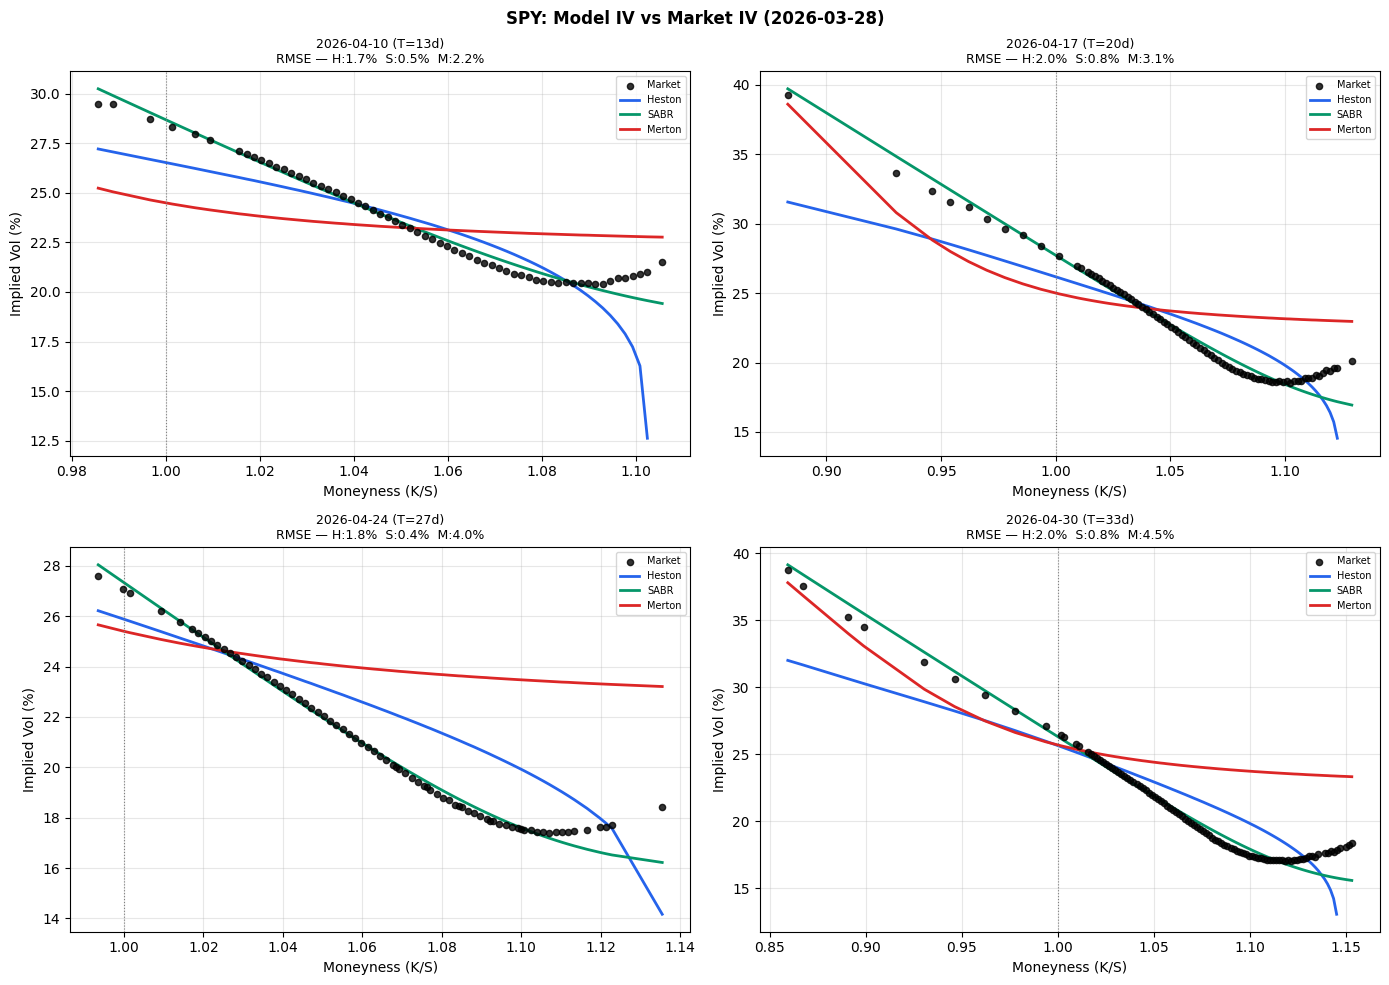

In [9]:
expiries_plot = sorted(cal_df["expiry"].unique())[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, exp in enumerate(expiries_plot):
    ax  = axes[i]
    sub = cal_df[cal_df["expiry"] == exp].sort_values("moneyness")
    T_val = sub["T"].iloc[0]

    ax.scatter(sub["moneyness"], sub["iv"]*100,
               s=20, color="black", zorder=5, label="Market", alpha=0.8)
    ax.plot(sub["moneyness"], sub["iv_heston"]*100,
            color="#2563EB", lw=2, label="Heston")
    ax.plot(sub["moneyness"], sub["iv_sabr"]*100,
            color="#059669", lw=2, label="SABR")
    ax.plot(sub["moneyness"], sub["iv_merton"]*100,
            color="#DC2626", lw=2, label="Merton")

    h_rmse = np.sqrt(((sub["iv_heston"]-sub["iv"])**2).mean())*100
    s_rmse = np.sqrt(((sub["iv_sabr"]  -sub["iv"])**2).mean())*100
    m_rmse = np.sqrt(((sub["iv_merton"]-sub["iv"])**2).mean())*100

    ax.set_title(f"{exp} (T={T_val*365:.0f}d)\n"
                 f"RMSE — H:{h_rmse:.1f}%  S:{s_rmse:.1f}%  M:{m_rmse:.1f}%",
                 fontsize=9)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Implied Vol (%)")
    ax.axvline(1.0, color="gray", ls=":", lw=0.8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f"SPY: Model IV vs Market IV ({snapshot_date})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/calibration_fit.png", dpi=150, bbox_inches="tight")
plt.show()

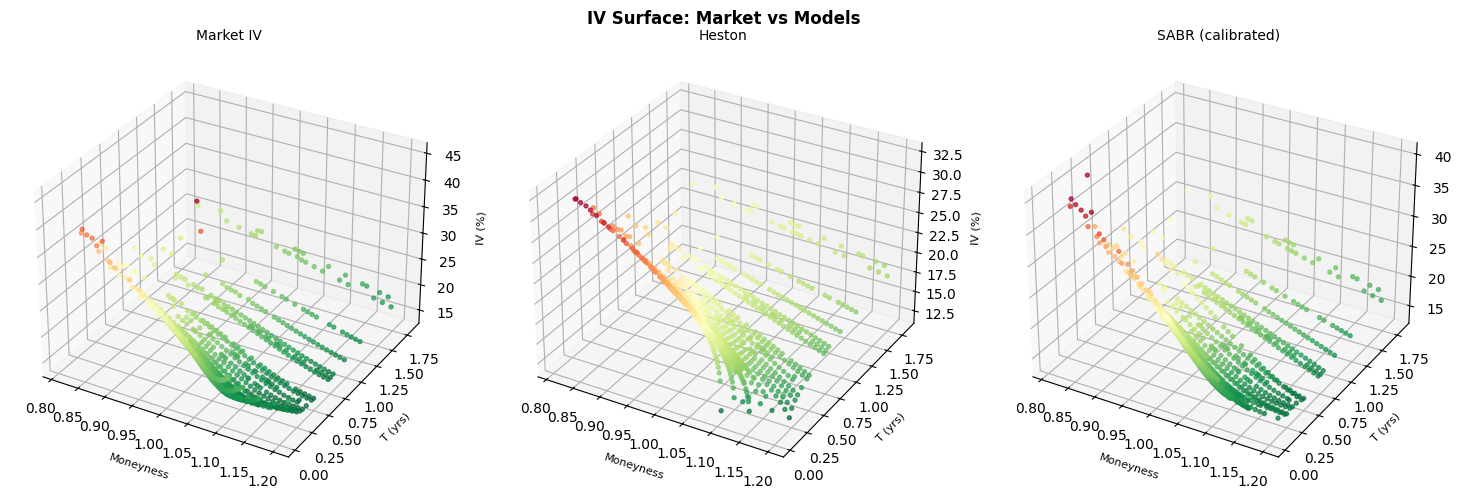

In [10]:
fig = plt.figure(figsize=(15, 5))
titles = ["Market IV", "Heston", "SABR (calibrated)"]
cols   = ["iv", "iv_heston", "iv_sabr"]

for idx, (title, col) in enumerate(zip(titles, cols)):
    ax  = fig.add_subplot(1, 3, idx+1, projection="3d")
    sub = cal_df.dropna(subset=[col])
    sc  = ax.scatter(sub["moneyness"], sub["T"], sub[col]*100,
                     c=sub[col]*100, cmap="RdYlGn_r", s=8, alpha=0.7)
    ax.set_xlabel("Moneyness", labelpad=5, fontsize=8)
    ax.set_ylabel("T (yrs)",   labelpad=5, fontsize=8)
    ax.set_zlabel("IV (%)",    labelpad=5, fontsize=8)
    ax.set_title(title, fontsize=10)

plt.suptitle("IV Surface: Market vs Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/iv_surface_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
calibrated_params = {
    "snapshot_date": snapshot_date,
    "market": {"S": S, "r": r, "q": q},
    "heston": {
        "kappa": kappa_h, "theta": theta_h, "xi": xi_h,
        "rho": rho_h, "v0": v0_h,
        "source": "calibrated",
        "rmse": float(np.sqrt((err_h**2).mean())*100)
    },
    "merton": {
        "sigma": sigma_m, "lam": lam_m,
        "mu_j": mu_j_m, "sigma_j": sigma_j_m,
        "source": "calibrated",
        "rmse": float(np.sqrt((err_m**2).mean())*100)
    },
    "sabr": {
        exp: {"alpha": float(a), "nu": float(n),
              "rho": float(rho_s), "rmse": float(rmse), "T": float(T_val)}
        for exp, (a, n, rho_s, rmse, T_val) in sabr_calibrated.items()
    },
}

os.makedirs("../data", exist_ok=True)
with open("../data/calibrated_params.json", "w") as f:
    json.dump(calibrated_params, f, indent=2)
print("Parameters saved to ../data/calibrated_params.json ✓")


Parameters saved to ../data/calibrated_params.json ✓


In [12]:
print("\n" + "="*60)
print("PHASE 6 SUMMARY")
print("="*60)

print("\nHeston (literature):")
print(f"  κ={kappa_h}, θ={theta_h}, ξ={xi_h}, ρ={rho_h}, v0={v0_h}")
print(f"  RMSE vs market: {np.sqrt((err_h**2).mean())*100:.2f}%")

print("\nMerton (literature):")
print(f"  σ={sigma_m}, λ={lam_m}, μ_j={mu_j_m}, σ_j={sigma_j_m}")
print(f"  RMSE vs market: {np.sqrt((err_m**2).mean())*100:.2f}%")

print("\nSABR (calibrated per slice):")
overall_sabr_rmse = np.sqrt((err_s**2).mean())*100
print(f"  Overall RMSE vs market: {overall_sabr_rmse:.2f}%")
for exp, (a, n, rho_s, rmse, T_val) in sorted(sabr_calibrated.items()):
    print(f"  {exp}: α={a:.3f}, ν={n:.3f}, ρ={rho_s:.3f}, "
          f"RMSE={rmse*100:.2f}%")

print("\n" + "="*60)
print("Phase 6 complete.")
print("All parameters saved. Ready for Phase 7 — Visualization.")
print("="*60)


PHASE 6 SUMMARY

Heston (literature):
  κ=4.806, θ=0.041, ξ=0.626, ρ=-0.934, v0=0.074
  RMSE vs market: 1.86%

Merton (literature):
  σ=0.21970971791744623, λ=0.5232579645318588, μ_j=-0.25714079065138007, σ_j=0.1
  RMSE vs market: 6.11%

SABR (calibrated per slice):
  Overall RMSE vs market: 0.97%
  2026-04-10: α=7.215, ν=2.462, ρ=-0.822, RMSE=0.49%
  2026-04-17: α=6.988, ν=2.212, ρ=-0.867, RMSE=0.80%
  2026-04-24: α=6.894, ν=2.386, ρ=-0.868, RMSE=0.39%
  2026-04-30: α=6.625, ν=1.948, ρ=-0.870, RMSE=0.81%
  2026-05-01: α=6.799, ν=2.308, ρ=-0.857, RMSE=0.29%
  2026-05-15: α=6.456, ν=1.851, ρ=-0.869, RMSE=0.66%
  2026-05-29: α=6.390, ν=2.013, ρ=-0.846, RMSE=0.25%
  2026-06-18: α=6.082, ν=1.552, ρ=-0.852, RMSE=0.46%
  2026-06-30: α=5.864, ν=1.477, ρ=-0.844, RMSE=0.41%
  2026-07-17: α=5.970, ν=1.636, ρ=-0.837, RMSE=0.09%
  2026-07-31: α=5.916, ν=1.465, ρ=-0.840, RMSE=0.11%
  2026-08-21: α=5.917, ν=1.359, ρ=-0.846, RMSE=0.12%
  2026-08-31: α=5.801, ν=1.045, ρ=-0.916, RMSE=0.19%
  2026-09-1